In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/gaming_churn.csv')
df.head()

,PlayerID,Age,Gender,Location,GameGenre,PlayTimeHours,InGamePurchases,GameDifficulty,SessionsPerWeek,AvgSessionDurationMinutes,PlayerLevel,AchievementsUnlocked,EngagementLevel
0,9000,43,Male,Other,Strategy,16.271119,0,Medium,6,108,79,25,Medium
1,9001,29,Female,USA,Strategy,5.525961,0,Medium,5,144,11,10,Medium
2,9002,22,Female,USA,Sports,8.223755,0,Easy,16,142,35,41,High
3,9003,35,Male,USA,Action,5.265351,1,Easy,9,85,57,47,Medium
4,9004,33,Male,Europe,Action,15.531945,0,Medium,2,131,95,37,Medium


In [2]:
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.describe())

(40034, 13)
PlayerID                       int64
Age                            int64
Gender                        object
Location                      object
GameGenre                     object
PlayTimeHours                float64
InGamePurchases                int64
GameDifficulty                object
SessionsPerWeek                int64
AvgSessionDurationMinutes      int64
PlayerLevel                    int64
AchievementsUnlocked           int64
EngagementLevel               object
dtype: object
PlayerID                     0
Age                          0
Gender                       0
Location                     0
GameGenre                    0
PlayTimeHours                0
InGamePurchases              0
GameDifficulty               0
SessionsPerWeek              0
AvgSessionDurationMinutes    0
PlayerLevel                  0
AchievementsUnlocked         0
EngagementLevel              0
dtype: int64
           PlayerID           Age  PlayTimeHours  InGamePurchases  \
count  4

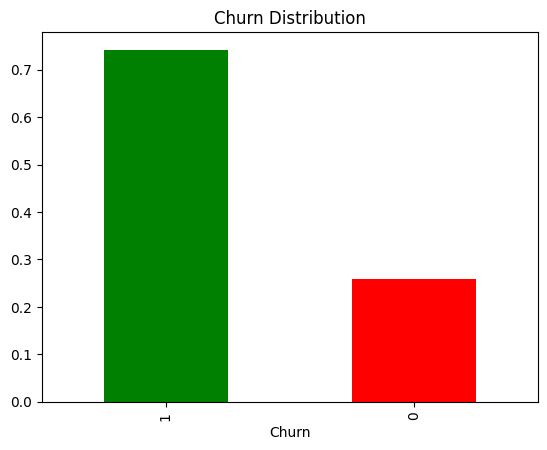

In [3]:
# EngagementLevel: High = retained, Medium/Low = at-risk/churned
# We convert it to binary churn
df['Churn'] = df['EngagementLevel'].apply(lambda x: 0 if x == 'High' else 1)
df['Churn'].value_counts(normalize=True).plot(kind='bar', color=['green','red'])
plt.title('Churn Distribution')
plt.savefig('../reports/churn_distribution.png')
plt.show()

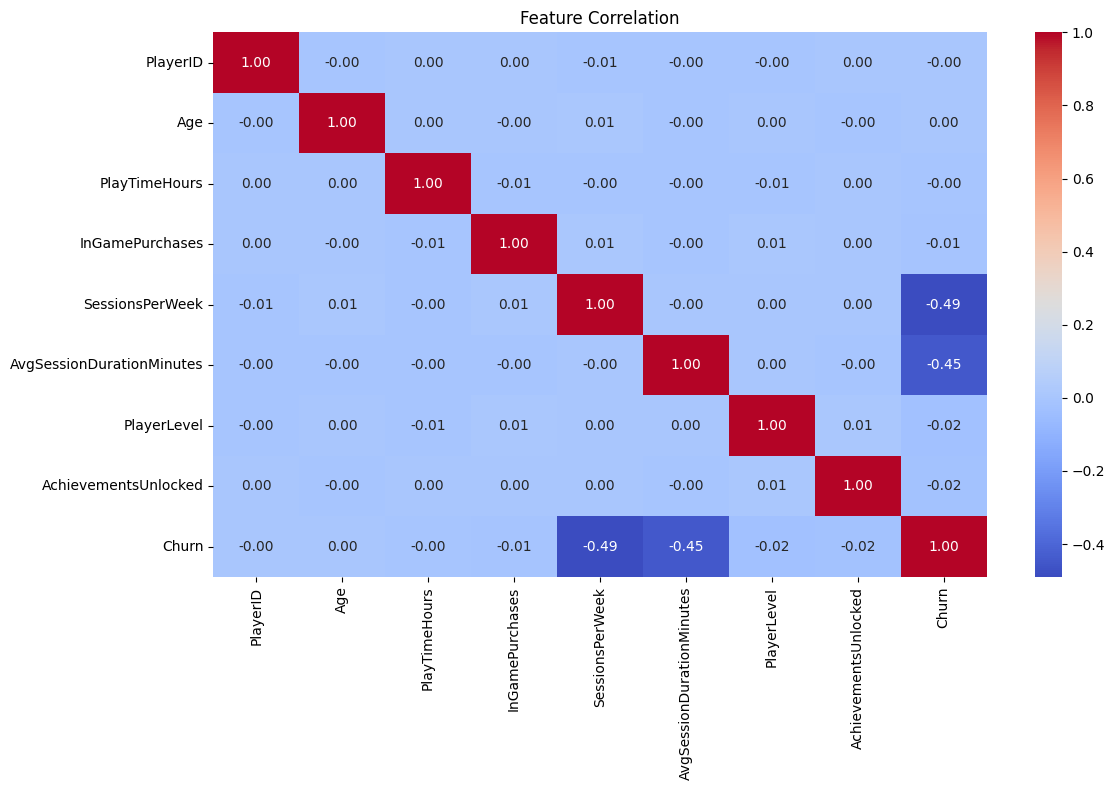

In [4]:
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation')
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png')
plt.show()

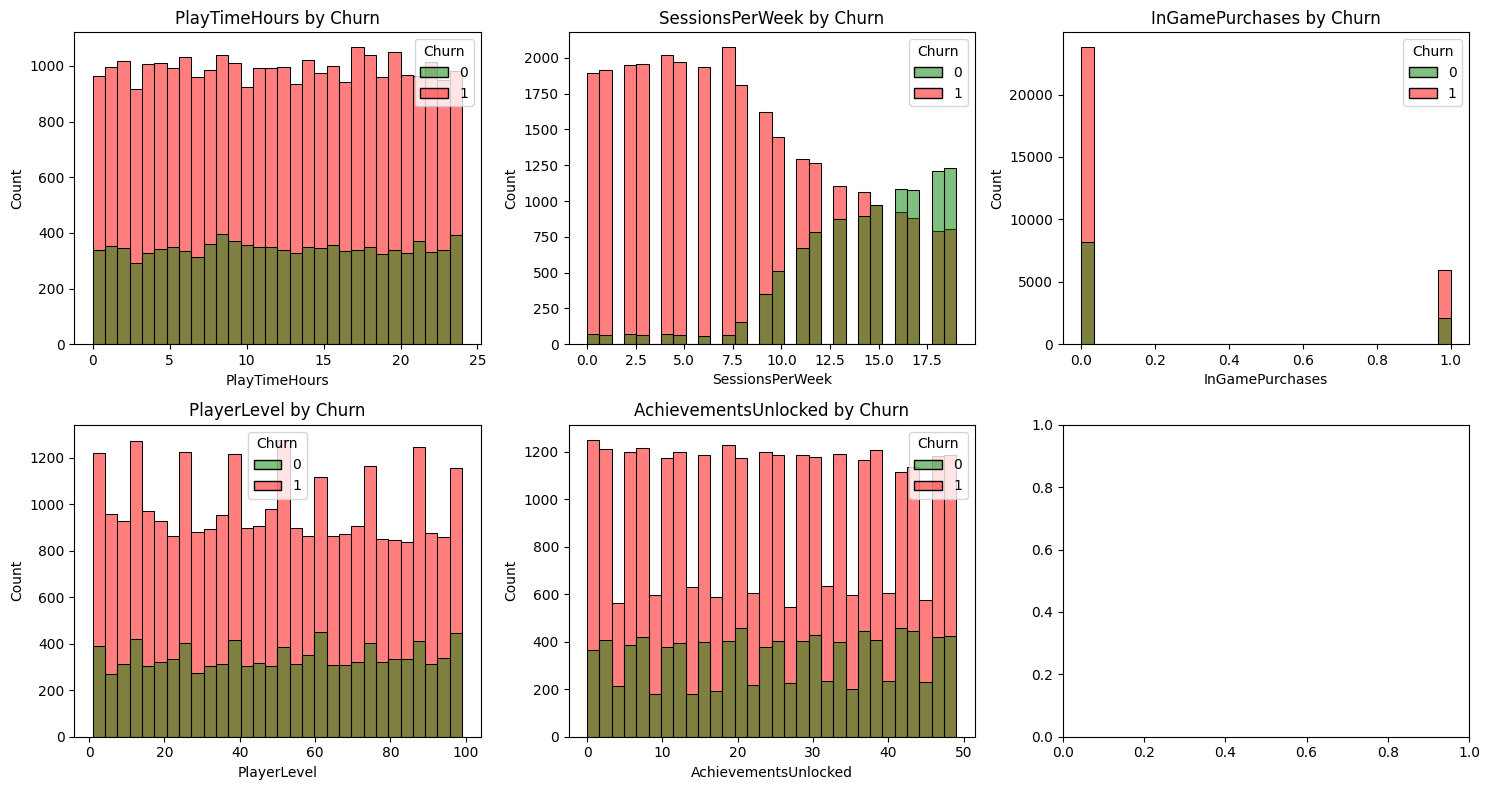

In [5]:
features = ['PlayTimeHours', 'SessionsPerWeek', 'InGamePurchases', 'PlayerLevel', 'AchievementsUnlocked']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(data=df, x=col, hue='Churn', bins=30, ax=axes[i], palette=['green','red'])
    axes[i].set_title(f'{col} by Churn')

plt.tight_layout()
plt.savefig('../reports/feature_distributions.png')
plt.show()


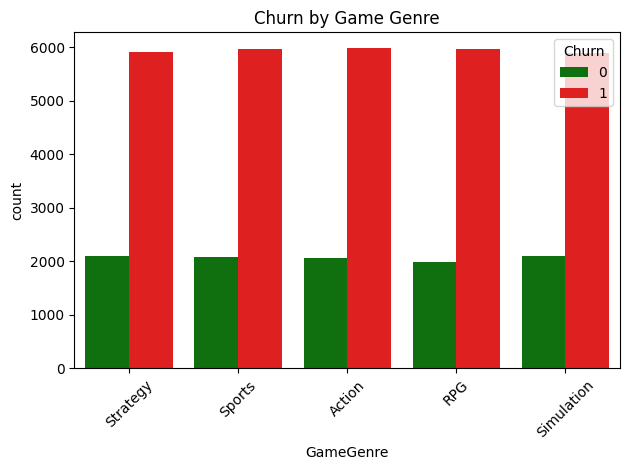

In [6]:
sns.countplot(data=df, x='GameGenre', hue='Churn', palette=['green','red'])
plt.title('Churn by Game Genre')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/churn_by_genre.png')
plt.show()